In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
smoke = pd.read_csv("visits_with_smoke_detailed.csv")

In [5]:
smoke.tail()
import pandas as pd

# Make sure 'date' is a datetime
smoke['date'] = pd.to_datetime(smoke['date'])

# Check min and max
print("Start date:", smoke['date'].min())
print("End date:", smoke['date'].max())

# Filter for dates up to Dec 31, 2023
smoke = smoke[smoke['date'] <= '2023-12-11']

# Optional: check new max
print("New end date:", smoke['date'].max())


Start date: 2022-01-01 00:00:00
End date: 2023-12-11 00:00:00
New end date: 2023-12-11 00:00:00


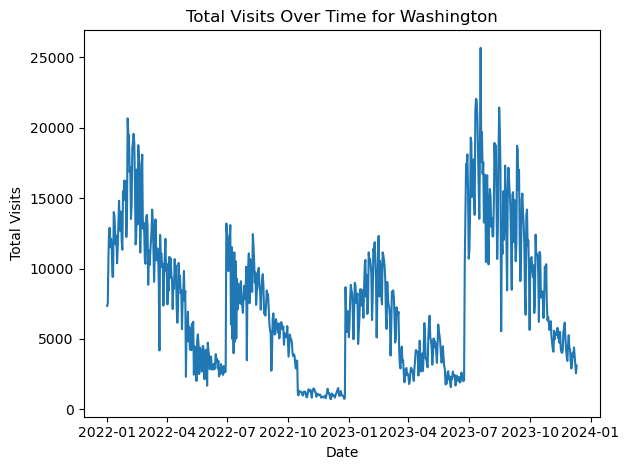

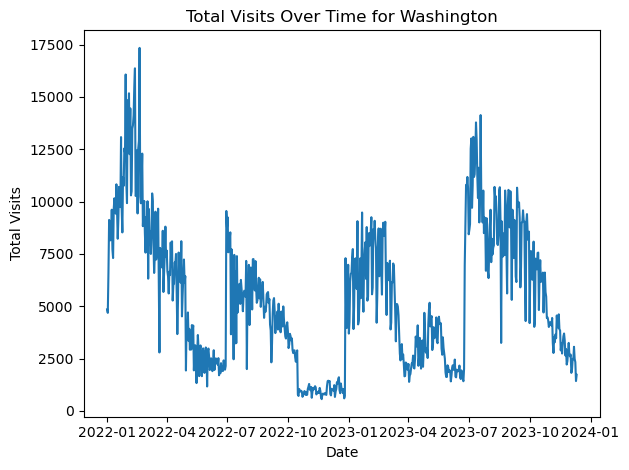

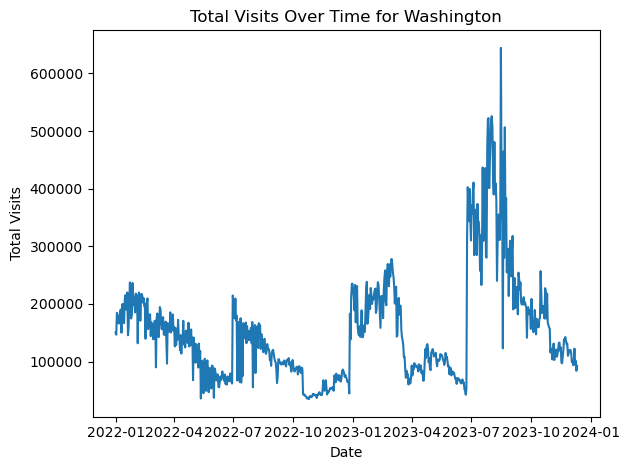

In [13]:
# Show visits over time for Washington
daily_visits = (
    smoke
    .groupby(['date','layer'])['unique_visits']
    .sum()
    .reset_index()
)
    # Scatter points
plt.plot(
    daily_visits[daily_visits['layer'] == "indoor_sports_facilities"]['date'],
    daily_visits[daily_visits['layer'] == "indoor_sports_facilities"]['unique_visits'],
)

plt.title("Total Visits Over Time for Washington")
plt.xlabel("Date")
plt.ylabel("Total Visits")
plt.tight_layout()
plt.show()
plt.plot(
    daily_visits[daily_visits['layer'] == "outdoor_sports_facilities"]['date'],
    daily_visits[daily_visits['layer'] == "outdoor_sports_facilities"]['unique_visits'],
)

plt.title("Total Visits Over Time for Washington")
plt.xlabel("Date")
plt.ylabel("Total Visits")
plt.tight_layout()
plt.show()
plt.plot(
    daily_visits[daily_visits['layer'] == "parks"]['date'],
    daily_visits[daily_visits['layer'] == "parks"]['unique_visits'],
)

plt.title("Total Visits Over Time for Washington")
plt.xlabel("Date")
plt.ylabel("Total Visits")
plt.tight_layout()
plt.show()


## Total Visit Numbers per Smoke Level

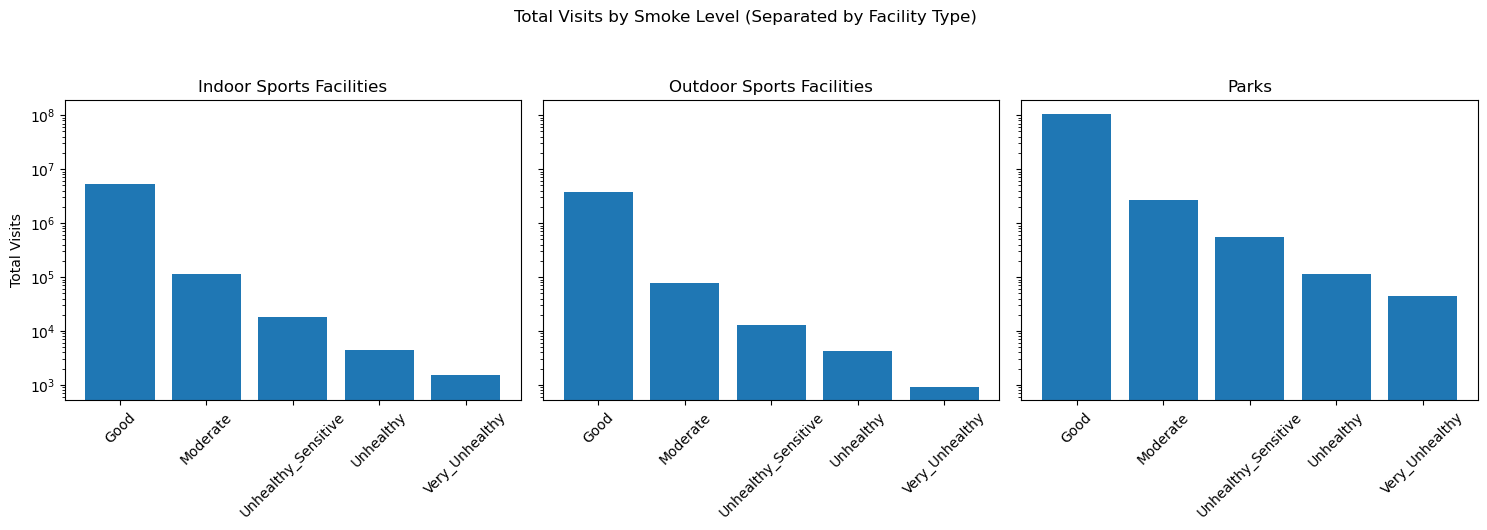

In [161]:
daily_visit_levels = (
    smoke
    .groupby(['smoke_category', 'layer'])['unique_visits']
    .sum()
    .reset_index()
)

# Optional ordering
smoke_order = [
    'Good',
    'Moderate',
    'Unhealthy_Sensitive',
    'Unhealthy',
    'Very_Unhealthy',
]

layers = daily_visit_levels['layer'].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(layers),
    figsize=(5 * len(layers), 5),
    sharey=True
)

for ax, layer in zip(axes, layers):
    df_layer = (
        daily_visit_levels[daily_visit_levels['layer'] == layer]
        .set_index('smoke_category')
        .loc[smoke_order]
    )

    ax.bar(df_layer.index, df_layer['unique_visits'])
    ax.set_title(layer.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=45)
    ax.set_yscale("log")


axes[0].set_ylabel("Total Visits")
fig.suptitle("Total Visits by Smoke Level (Separated by Facility Type)", y=1.05)

plt.tight_layout()
plt.show()





## City level total visitation distribution.

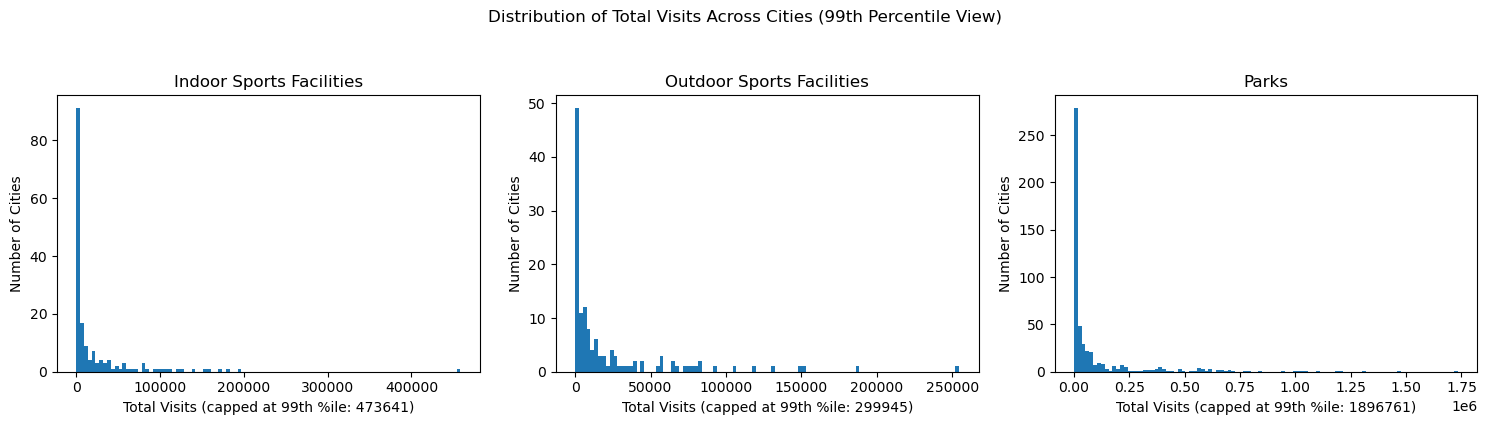

In [224]:
daily_visit_levels = (
    smoke
    .groupby(['city', 'layer'])['unique_visits']
    .sum()
    .reset_index()
)
layers = daily_visit_levels['layer'].unique()
fig, axes = plt.subplots(
    1, len(layers),
    figsize=(5 * len(layers), 4),
    sharey=False  # Changed from True
)
for ax, layer in zip(axes, layers):
    df_layer = daily_visit_levels[
        daily_visit_levels['layer'] == layer
    ]
    
    # Cap at 99th percentile
    p99 = df_layer['unique_visits'].quantile(0.99)
    df_capped = df_layer[df_layer['unique_visits'] <= p99]
    
    ax.hist(df_capped['unique_visits'], bins=100)
    ax.set_title(layer.replace('_', ' ').title())
    ax.set_xlabel(f"Total Visits (capped at 99th %ile: {p99:.0f})")
    ax.set_ylabel("Number of Cities") 
fig.suptitle("Distribution of Total Visits Across Cities (99th Percentile View)", y=1.05)
plt.tight_layout()
plt.show()

In [150]:
smoke["date"] = pd.to_datetime(smoke["date"])
smoke = smoke.sort_values(["city", "layer", "date"]).reset_index(drop=True)

#create a three month centered average, for now
rolled = (
    smoke
    .groupby(["city", "layer"])
    .rolling("30D", on="date", center=False)["unique_visits"]
    .mean()
    .rename("visits_3mo_ma_centered")
    .reset_index()
)

smoke = smoke.merge(
    rolled,
    on=["city", "layer", "date"],
    how="left"
)

summary = np.zeros((6, 3))

for i, category in enumerate([
    'Good','Moderate','Unhealthy_Sensitive',
    'Unhealthy','Very_Unhealthy','Hazardous'
]):
    for j, layer in enumerate([
        "parks", "outdoor_sports_facilities", "indoor_sports_facilities"
    ]):

        summary_data = smoke[
            (smoke["smoke_category"] == category) &
            (smoke["layer"] == layer)
        ]

        if len(summary_data) > 0:
            pct_change = (
                (summary_data["unique_visits"]
                 - summary_data["visits_3mo_ma_centered"])
                / summary_data["visits_3mo_ma_centered"]
            )

            summary[i, j] = pct_change.mean()
        else:
            summary[i, j] = np.nan




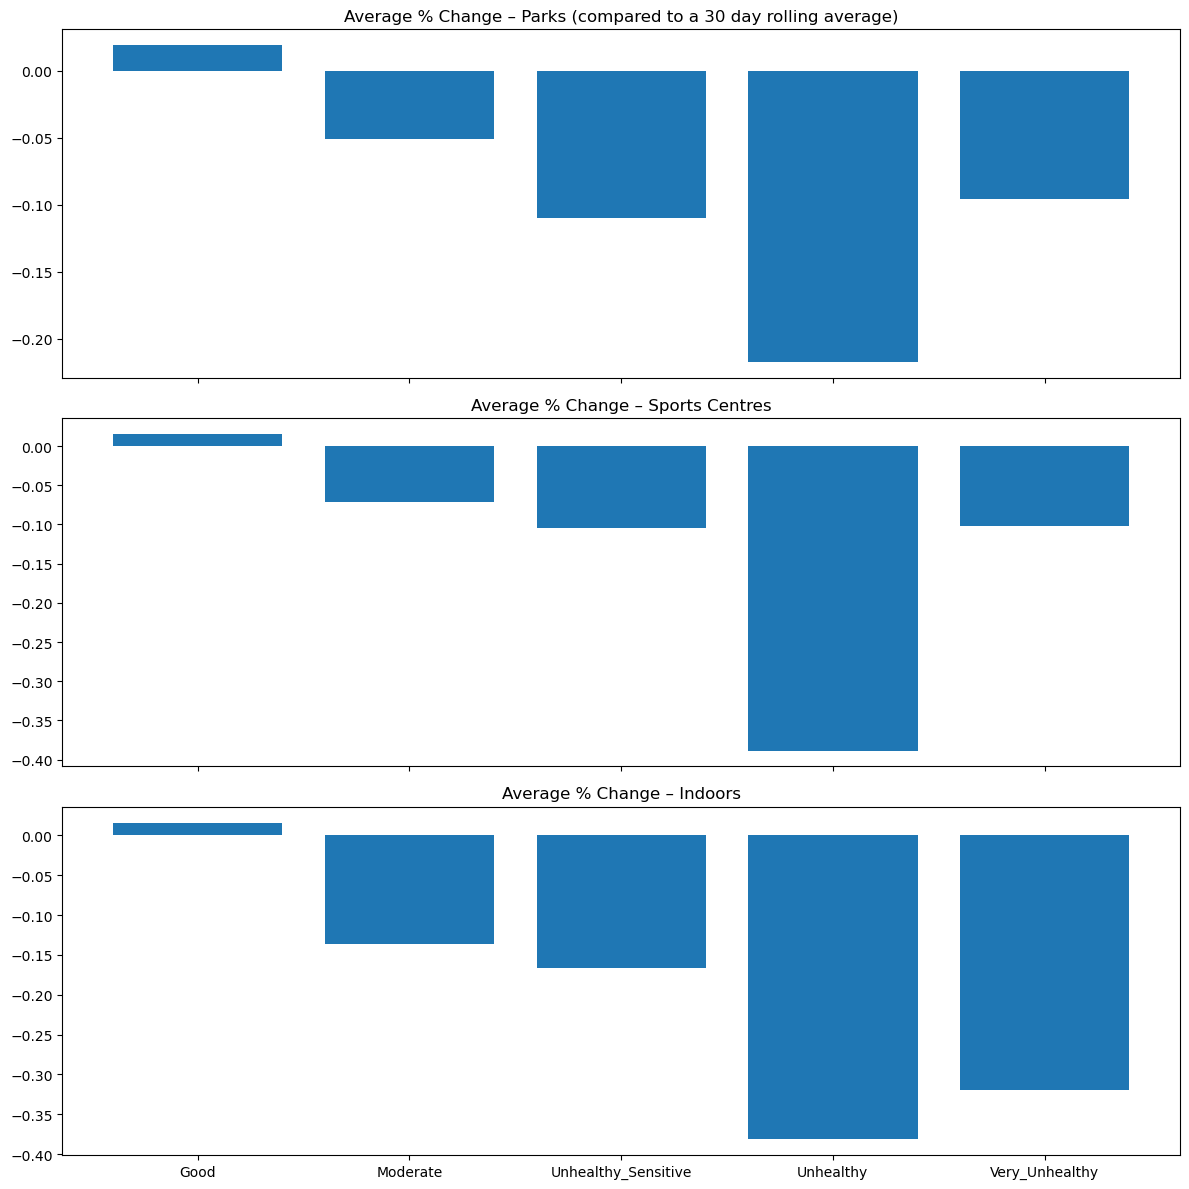

In [188]:
import matplotlib.pyplot as plt

categories = ['Good','Moderate','Unhealthy_Sensitive','Unhealthy','Very_Unhealthy','Hazardous']

fig, axes = plt.subplots(nrows=3,figsize=(12, 12), sharex=True)

# --- Row 1: Parks ---
axes[0].bar(categories, summary[:, 0])
axes[0].set_title("Average % Change – Parks (compared to a 30 day rolling average)")

# --- Row 2: Sports Centres ---
axes[1].bar(categories, summary[:, 1])
axes[1].set_title("Average % Change – Sports Centres")


# --- Row 3: Indoors ---
axes[2].bar(categories, summary[:, 2])
axes[2].set_title("Average % Change – Indoors")


plt.tight_layout()
plt.show()





### Poisson model (to plot residuals vs smoke)

KeyboardInterrupt: 

In [207]:
smoke

,city,date,layer,unique_visits,city_name,weighted_avg_smoke_pm,n_grids,smoke_category,visits_1mo_rolling,pct_change
0,Aberdeen,2022-01-01,indoor_sports_facilities,3,Aberdeen,0.0,0.0,Good,3.000000,0.000000
1,Aberdeen,2022-01-02,indoor_sports_facilities,1,Aberdeen,0.0,0.0,Good,2.000000,-0.500000
2,Aberdeen,2022-01-04,indoor_sports_facilities,2,Aberdeen,0.0,0.0,Good,2.000000,0.000000
3,Aberdeen,2022-01-05,indoor_sports_facilities,2,Aberdeen,0.0,0.0,Good,2.000000,0.000000
4,Aberdeen,2022-01-08,indoor_sports_facilities,2,Aberdeen,0.0,0.0,Good,2.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
415370,Zillah,2023-12-07,parks,42,Zillah,0.0,0.0,Good,66.600000,-0.369369
415371,Zillah,2023-12-08,parks,13,Zillah,0.0,0.0,Good,64.533333,-0.798554
415372,Zillah,2023-12-09,parks,16,Zillah,0.0,0.0,Good,62.366667,-0.743453
415373,Zillah,2023-12-10,parks,15,Zillah,0.0,0.0,Good,61.966667,-0.757934


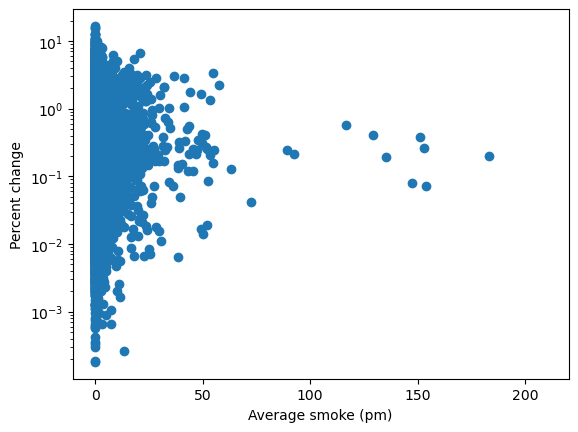

In [223]:
smoke_parks = smoke[smoke["layer"] == "indoor_sports_facilities"]
smoke_larger_parks = smoke_parks[smoke_parks["visits_1mo_rolling"] >10]
plt.scatter(smoke_larger_parks["weighted_avg_smoke_pm"], smoke_larger_parks["pct_change"])
plt.xlabel("Average smoke (pm)")
plt.ylabel("Percent change")
plt.yscale("log")
plt.show()

In [213]:
smoke["pct_change"].describe()

count    415375.000000
mean          0.014890
std           0.837121
min          -0.993498
25%          -0.436620
50%          -0.137267
75%           0.200000
max          20.743363
Name: pct_change, dtype: float64